# Phase 7 — Explainable Recommendation

## Step 1 — Mount Google Drive


In [5]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2 — Configure the explanation experiment


In [6]:
from pathlib import Path
import gc
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import shap
import tensorflow as tf
from tensorflow import keras

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.keras.utils.set_random_seed(RANDOM_STATE)

PRIMARY_POLICY = 'all_supported'
PRIMARY_RELEVANCE = 'attempted'
PRIMARY_K = 10
SHAP_LEARNERS = 24
SHAP_RECENT_EVENTS = 20
SHAP_NSAMPLES = 256
SHAP_STABILITY_CASES = 3
FIDELITY_TOLERANCE = 1e-10
EXPECTED_PHASE6_TARGET_SUCCESS = 0.55
EXPECTED_PHASE6_DKT_WEIGHT = 0.02

DRIVE_ROOT = Path('/content/drive/MyDrive/datasets')
RAW_PATH = DRIVE_ROOT / '2012-2013-data-with-predictions-4-final.csv'
PHASE2_ROOT = DRIVE_ROOT / 'recommendation_benchmark_final_outputs' / 'assistments'
PHASE4_ROOT = DRIVE_ROOT / 'hybrid_recommender_gated_final_outputs'
PHASE6_ROOT = DRIVE_ROOT / 'sequential_learner_model_outputs'
OUTPUT_ROOT = DRIVE_ROOT / 'explainable_recommendation_outputs'
FIGURE_ROOT = OUTPUT_ROOT / 'figures'
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)

print('SHAP:', shap.__version__)
print('Output directory:', OUTPUT_ROOT)

SHAP: 0.52.0
Output directory: /content/drive/MyDrive/datasets/explainable_recommendation_outputs


## Step 3 — Load the previous


In [7]:
with open(PHASE6_ROOT / 'phase6_config.json', encoding='utf-8') as file:
    phase6_config = json.load(file)
with open(PHASE6_ROOT / 'skill_vocabulary.json', encoding='utf-8') as file:
    vocabulary = json.load(file)

selected_model = phase6_config['selected_project_model']
selected_target_from_handoff = float(phase6_config['selected_target_success'])
selected_weight_from_handoff = float(phase6_config['selected_dkt_weight'])


recommendations = pd.read_parquet(
    PHASE6_ROOT / 'sequential_hybrid_recommendations.parquet'
)
phase4_contributions = pd.read_parquet(
    PHASE4_ROOT / 'hybrid_component_contributions.parquet'
)
validation_skill_states = pd.read_parquet(
    PHASE6_ROOT / 'validation_skill_states.parquet'
)
validation_state_summary = pd.read_csv(
    PHASE6_ROOT / 'validation_state_summary.csv', dtype={'learner_id': str}
)
dkt_contribution_diagnostics = pd.read_csv(
    PHASE6_ROOT / 'dkt_contribution_diagnostics.csv'
)
learners = pd.read_parquet(PHASE2_ROOT / 'learner_splits.parquet')
skill_catalog = pd.read_parquet(PHASE2_ROOT / 'skill_catalog.parquet')
problem_catalog = pd.read_parquet(PHASE2_ROOT / 'problem_catalog.parquet')
problem_skill_map = pd.read_parquet(PHASE2_ROOT / 'problem_skill_map.parquet')
skill_name_map = pd.read_parquet(PHASE2_ROOT / 'skill_name_id_map.parquet')
early_problem = pd.read_parquet(PHASE2_ROOT / 'early_problem_history.parquet')
dkt_model = keras.models.load_model(
    PHASE6_ROOT / 'lstm_dkt_model.keras', compile=False
)

for frame in [recommendations, phase4_contributions, learners,
              validation_skill_states, validation_state_summary, early_problem]:
    if 'learner_id' in frame:
        frame['learner_id'] = frame['learner_id'].astype(str)
for frame in [recommendations, phase4_contributions, problem_catalog,
              skill_catalog, early_problem]:
    if 'item_id' in frame:
        frame['item_id'] = frame['item_id'].astype(str)
problem_skill_map['problem_item_id'] = problem_skill_map['problem_item_id'].astype(str)
problem_skill_map['skill_item_id'] = problem_skill_map['skill_item_id'].astype(str)
validation_skill_states['skill_item_id'] = (
    validation_skill_states['skill_item_id'].astype(str)
)

handoff_summary = pd.DataFrame([
    {'Input': 'Phase 6 recommendations', 'Rows': len(recommendations),
     'Learners': recommendations['learner_id'].nunique()},
    {'Input': 'Phase 4 component contributions', 'Rows': len(phase4_contributions),
     'Learners': phase4_contributions['learner_id'].nunique()},
    {'Input': 'Validation skill states', 'Rows': len(validation_skill_states),
     'Learners': validation_skill_states['learner_id'].nunique()},
    {'Input': 'Validation state summary', 'Rows': len(validation_state_summary),
     'Learners': validation_state_summary['learner_id'].nunique()},
    {'Input': 'DKT contribution diagnostics',
     'Rows': len(dkt_contribution_diagnostics), 'Learners': np.nan},
])
display(handoff_summary)
display(validation_state_summary['StateSource'].value_counts(dropna=False))
display(dkt_contribution_diagnostics)

,Input,Rows,Learners
0,Phase 6 recommendations,533360,6667.0
1,Phase 4 component contributions,500538,6667.0
2,Validation skill states,1073387,6667.0
3,Validation state summary,6667,6667.0
4,DKT contribution diagnostics,8,NaN


,count
StateSource,
lstm_dkt_early_history,4162
discovery_skill_prior,2505


,CandidatePolicy,RelevanceDefinition,dkt_state_source,ContributionRows,ContributingLearners,MeanHistoryEvidenceStrength
0,all_supported,attempted,discovery_skill_prior,7077,679,0.000000
1,all_supported,attempted,lstm_dkt_early_history,1115,413,0.566959
2,all_supported,successful,discovery_skill_prior,7822,747,0.000000
3,all_supported,successful,lstm_dkt_early_history,1143,407,0.527153
4,novel_only,attempted,discovery_skill_prior,7581,739,0.000000
5,novel_only,attempted,lstm_dkt_early_history,1310,419,0.513761
6,novel_only,successful,discovery_skill_prior,8201,816,0.000000
7,novel_only,successful,lstm_dkt_early_history,1403,423,0.474241


## Step 4 — Reconstruct hierarchical final-score provenance

Phase 6 combines the previous hybrid rank with DKT. This cell joins the Phase 4 contribution rows and allocates the Phase 6 base contribution across CF, first-order sequence and content. Popularity remains a separate fallback. The resulting nested components sum back to the Phase 6 score.

In [8]:
join_keys = [
    'CandidatePolicy', 'RelevanceDefinition', 'learner_id', 'item_id'
]


phase4_nested = phase4_contributions[[
    *join_keys, 'score_source', 'FallbackUsed',
    'cf_contribution', 'sequential_contribution', 'content_contribution',
]].rename(columns={
    'score_source': 'phase4_score_source',
    'FallbackUsed': 'phase4_fallback_used',
    'cf_contribution': 'phase4_cf_raw',
    'sequential_contribution': 'phase4_sequential_raw',
    'content_contribution': 'phase4_content_raw',
})

hybrid_attributions = recommendations.merge(
    phase4_nested, on=join_keys, how='left', validate='many_to_one'
)
raw_columns = [
    'phase4_cf_raw', 'phase4_sequential_raw', 'phase4_content_raw'
]
hybrid_attributions[raw_columns] = (
    hybrid_attributions[raw_columns].fillna(0.0).astype(float)
)
hybrid_attributions['phase4_fallback_used'] = (
    hybrid_attributions['phase4_fallback_used'].eq(True)
)
hybrid_attributions['raw_base_total'] = hybrid_attributions[raw_columns].sum(axis=1)
known_base = hybrid_attributions['raw_base_total'].gt(0)
base_scale = np.divide(
    hybrid_attributions['base_contribution'].to_numpy(dtype=float),
    hybrid_attributions['raw_base_total'].to_numpy(dtype=float),
    out=np.zeros(len(hybrid_attributions), dtype=float),
    where=known_base.to_numpy(),
)
hybrid_attributions['cf_attribution'] = (
    hybrid_attributions['phase4_cf_raw'] * base_scale
)
hybrid_attributions['sequential_attribution'] = (
    hybrid_attributions['phase4_sequential_raw'] * base_scale
)
hybrid_attributions['content_attribution'] = (
    hybrid_attributions['phase4_content_raw'] * base_scale
)
popularity_mask = (
    hybrid_attributions['base_contribution'].gt(0)
    & ~known_base
    & hybrid_attributions['phase4_fallback_used']
)
hybrid_attributions['popularity_attribution'] = np.where(
    popularity_mask, hybrid_attributions['base_contribution'], 0.0
)
unknown_base_mask = (
    hybrid_attributions['base_contribution'].gt(0)
    & ~known_base
    & ~hybrid_attributions['phase4_fallback_used']
)
hybrid_attributions['unresolved_base_attribution'] = np.where(
    unknown_base_mask, hybrid_attributions['base_contribution'], 0.0
)
hybrid_attributions['dkt_attribution'] = (
    hybrid_attributions['dkt_contribution'].fillna(0.0).astype(float)
)

component_columns = [
    'cf_attribution', 'sequential_attribution', 'content_attribution',
    'popularity_attribution', 'unresolved_base_attribution', 'dkt_attribution',
]
hybrid_attributions['nested_base_total'] = hybrid_attributions[[
    'cf_attribution', 'sequential_attribution', 'content_attribution',
    'popularity_attribution', 'unresolved_base_attribution',
]].sum(axis=1)
hybrid_attributions['attributed_score'] = hybrid_attributions[
    component_columns
].sum(axis=1)
hybrid_attributions['base_fidelity_error'] = (
    hybrid_attributions['nested_base_total']
    - hybrid_attributions['base_contribution']
).abs()
hybrid_attributions['score_fidelity_error'] = (
    hybrid_attributions['attributed_score']
    - hybrid_attributions['score']
).abs()
hybrid_attributions['dominant_component'] = (
    hybrid_attributions[component_columns]
    .rename(columns=lambda value: value.replace('_attribution', ''))
    .idxmax(axis=1)
)
hybrid_attributions['dominant_component_share'] = np.divide(
    hybrid_attributions[component_columns].max(axis=1).to_numpy(dtype=float),
    hybrid_attributions['attributed_score'].to_numpy(dtype=float),
    out=np.zeros(len(hybrid_attributions), dtype=float),
    where=hybrid_attributions['attributed_score'].gt(0).to_numpy(),
)

provenance_fidelity = pd.DataFrame([{
    'RecommendationRows': len(hybrid_attributions),
    'MaximumBaseFidelityError': hybrid_attributions['base_fidelity_error'].max(),
    'MaximumScoreFidelityError': hybrid_attributions['score_fidelity_error'].max(),
    'RowsWithUnresolvedBase': int(unknown_base_mask.sum()),
    'RowsWithPhase4Match': int(
        hybrid_attributions['phase4_score_source'].notna().sum()
    ),
}])
display(provenance_fidelity)
display(hybrid_attributions[[
    *join_keys, 'rank', 'score', 'dominant_component',
    'dominant_component_share', 'dkt_state_source',
]].head())

,RecommendationRows,MaximumBaseFidelityError,MaximumScoreFidelityError,RowsWithUnresolvedBase,RowsWithPhase4Match
0,533360,3.469447e-18,3.469447e-18,0,500538


,CandidatePolicy,RelevanceDefinition,learner_id,item_id,rank,score,dominant_component,dominant_component_share,dkt_state_source
0,all_supported,attempted,100516,problem:30342,1,0.016393,cf,1.0,None
1,all_supported,attempted,100516,problem:30174,2,0.016129,cf,1.0,None
2,all_supported,attempted,100516,problem:4674,3,0.015873,cf,1.0,None
3,all_supported,attempted,100516,problem:2264,4,0.015625,cf,1.0,None
4,all_supported,attempted,100516,problem:14841,5,0.015385,cf,1.0,None


## Step 5 — Attach learner, skill, item and history evidence

Cold-start status , readable identifiers, a frozen problem-to-skill association, saved DKT skill-state predictions and early problem-history summaries are added to Explanation rows.

In [9]:
def choose_label_column(frame, candidates):
    return next((column for column in candidates if column in frame.columns), None)


problem_label_column = choose_label_column(
    problem_catalog, ['problem_name', 'item_name', 'name', 'title', 'original_id']
)
skill_label_column = choose_label_column(
    skill_catalog, ['skill_name', 'item_name', 'name', 'title', 'original_name']
)
problem_labels = problem_catalog[['item_id']].copy()
problem_labels['problem_label'] = (
    problem_catalog[problem_label_column].where(
        problem_catalog[problem_label_column].notna(),
        problem_catalog['item_id'],
    ).astype(str)
    if problem_label_column else problem_catalog['item_id'].astype(str)
)
skill_labels = skill_catalog[['item_id']].copy()
skill_labels['skill_label'] = (
    skill_catalog[skill_label_column].where(
        skill_catalog[skill_label_column].notna(),
        skill_catalog['item_id'],
    ).astype(str)
    if skill_label_column else skill_catalog['item_id'].astype(str)
)
skill_labels = skill_labels.rename(columns={'item_id': 'primary_skill_id'})

sort_columns = ['problem_item_id']
ascending = [True]
if 'association_share' in problem_skill_map.columns:
    sort_columns = ['problem_item_id', 'association_share']
    ascending = [True, False]
primary_problem_skill = (
    problem_skill_map.sort_values(sort_columns, ascending=ascending, kind='mergesort')
    .drop_duplicates('problem_item_id')
    [['problem_item_id', 'skill_item_id']]
    .rename(columns={
        'problem_item_id': 'item_id',
        'skill_item_id': 'mapped_skill_id',
    })
)

explanation_rows = hybrid_attributions.merge(
    problem_labels, on='item_id', how='left', validate='many_to_one'
).merge(
    primary_problem_skill, on='item_id', how='left', validate='many_to_one'
)
explanation_rows['primary_skill_id'] = (
    explanation_rows['supporting_skill_id'].astype('string')
    .fillna(explanation_rows['mapped_skill_id'].astype('string'))
)
explanation_rows = explanation_rows.merge(
    skill_labels, on='primary_skill_id', how='left', validate='many_to_one'
)

learner_columns = ['learner_id']
if 'cold_start_problem_history' in learners.columns:
    learner_columns.append('cold_start_problem_history')
explanation_rows = explanation_rows.merge(
    learners[learner_columns], on='learner_id', how='left', validate='many_to_one'
)
if 'cold_start_problem_history' not in explanation_rows.columns:
    explanation_rows['cold_start_problem_history'] = False
explanation_rows['cold_start_problem_history'] = (
    explanation_rows['cold_start_problem_history'].fillna(False).astype(bool)
)

state_pairs = explanation_rows[[
    'learner_id', 'primary_skill_id'
]].dropna().drop_duplicates()
state_pairs = state_pairs.merge(
    validation_skill_states[[
        'learner_id', 'skill_item_id', 'PredictedCorrectness',
        'SupportedEarlyInteractionsUsed', 'StateSource',
        'HistoryEvidenceStrength',
    ]],
    left_on=['learner_id', 'primary_skill_id'],
    right_on=['learner_id', 'skill_item_id'],
    how='left', validate='one_to_one',
).drop(columns='skill_item_id')
state_pairs = state_pairs.rename(columns={
    'PredictedCorrectness': 'skill_state_predicted_correctness',
    'SupportedEarlyInteractionsUsed': 'state_history_count',
    'StateSource': 'state_source_for_primary_skill',
    'HistoryEvidenceStrength': 'state_evidence_strength',
})
explanation_rows = explanation_rows.merge(
    state_pairs, on=['learner_id', 'primary_skill_id'],
    how='left', validate='many_to_one',
)
explanation_rows['explanation_predicted_correctness'] = (
    explanation_rows['predicted_correctness']
    .fillna(explanation_rows['skill_state_predicted_correctness'])
)
selected_target = float(phase6_config['selected_target_success'])
explanation_rows['target_distance'] = (
    explanation_rows['explanation_predicted_correctness'] - selected_target
).abs()

history_columns = [
    column for column in [
        'learner_id', 'item_id', 'early_interaction_count',
        'early_correct_count', 'early_success_rate',
        'early_last_event_number', 'early_last_event_time',
    ] if column in early_problem.columns
]
explanation_rows = explanation_rows.merge(
    early_problem[history_columns],
    on=['learner_id', 'item_id'], how='left', validate='many_to_one',
)
explanation_rows['previously_seen_problem'] = (
    explanation_rows.get(
        'early_interaction_count',
        pd.Series(0, index=explanation_rows.index),
    ).fillna(0).gt(0)
)
display(explanation_rows[[
    'learner_id', 'item_id', 'rank', 'problem_label', 'primary_skill_id',
    'skill_label', 'explanation_predicted_correctness',
    'state_source_for_primary_skill', 'previously_seen_problem',
]].head())

,learner_id,item_id,rank,problem_label,primary_skill_id,skill_label,explanation_predicted_correctness,state_source_for_primary_skill,previously_seen_problem
0,100516,problem:30342,1,problem:30342,skill:id:18,skill:id:18,0.792007,lstm_dkt_early_history,False
1,100516,problem:30174,2,problem:30174,skill:id:16,skill:id:16,0.851861,lstm_dkt_early_history,False
2,100516,problem:4674,3,problem:4674,skill:id:11,skill:id:11,0.642643,lstm_dkt_early_history,False
3,100516,problem:2264,4,problem:2264,skill:id:12,skill:id:12,0.722397,lstm_dkt_early_history,False
4,100516,problem:14841,5,problem:14841,skill:id:75,skill:id:75,0.824255,lstm_dkt_early_history,False


## Step 6 — Summarise exact component use globally

Exact contribution magnitude and route frequency answer different questions. This cell reports both.

Summaries are broken down by cold-start status, candidate policy, relevance definition and DKT state source.

In [10]:
component_names = {
    'cf_attribution': 'collaborative_filtering',
    'sequential_attribution': 'first_order_sequence',
    'content_attribution': 'content',
    'popularity_attribution': 'popularity_fallback',
    'unresolved_base_attribution': 'unresolved_base',
    'dkt_attribution': 'lstm_dkt_extension',
}
component_summary_rows = []
for column, component in component_names.items():
    positive = explanation_rows[column].gt(0)
    component_summary_rows.append({
        'Component': component,
        'ContributionRows': int(positive.sum()),
        'ContributingLearners': int(
            explanation_rows.loc[positive, 'learner_id'].nunique()
        ),
        'RecommendationRowRate': float(positive.mean()),
        'MeanContributionWhenPresent': float(
            explanation_rows.loc[positive, column].mean()
        ) if positive.any() else 0.0,
        'TotalContribution': float(explanation_rows[column].sum()),
        'MeanShareOfFinalScore': float(np.divide(
            explanation_rows[column].to_numpy(dtype=float),
            explanation_rows['score'].to_numpy(dtype=float),
            out=np.zeros(len(explanation_rows), dtype=float),
            where=explanation_rows['score'].gt(0).to_numpy(),
        ).mean()),
    })
global_component_summary = pd.DataFrame(component_summary_rows)

route_summary = (
    explanation_rows.groupby([
        'CandidatePolicy', 'RelevanceDefinition',
        'cold_start_problem_history', 'dominant_component',
        'dkt_state_source',
    ], dropna=False).agg(
        RecommendationRows=('item_id', 'size'),
        Learners=('learner_id', 'nunique'),
        MeanRank=('rank', 'mean'),
        MeanDominantShare=('dominant_component_share', 'mean'),
    ).reset_index()
)
display(global_component_summary.sort_values(
    'TotalContribution', ascending=False
))
display(route_summary.head(20))

,Component,ContributionRows,ContributingLearners,RecommendationRowRate,MeanContributionWhenPresent,TotalContribution,MeanShareOfFinalScore
0,collaborative_filtering,470752,6377,0.882616,0.014331,6746.412207,0.882327
3,popularity_fallback,18160,316,0.034048,0.014280,259.332850,0.034048
2,content,17963,1296,0.033679,0.007920,142.273818,0.019342
1,first_order_sequence,1420,162,0.002662,0.015159,21.526348,0.002662
5,lstm_dkt_extension,35652,1544,0.066844,0.000293,10.437858,0.061620
4,unresolved_base,0,0,0.000000,0.000000,0.000000,0.000000


,CandidatePolicy,RelevanceDefinition,cold_start_problem_history,dominant_component,dkt_state_source,RecommendationRows,Learners,MeanRank,MeanDominantShare
0,all_supported,attempted,False,cf,lstm_dkt_early_history,734,376,10.129428,0.983602
1,all_supported,attempted,False,cf,NaN,119758,6377,10.285376,0.999737
2,all_supported,attempted,False,content,lstm_dkt_early_history,2,1,12.000000,0.986779
3,all_supported,attempted,False,content,NaN,1565,127,13.463898,1.000000
4,all_supported,attempted,False,dkt,discovery_skill_prior,7077,679,13.608874,1.000000
5,all_supported,attempted,False,dkt,lstm_dkt_early_history,379,37,14.031662,1.000000
6,all_supported,attempted,False,sequential,NaN,545,126,6.818349,1.000000
7,all_supported,attempted,True,content,NaN,460,23,10.500000,1.000000
8,all_supported,attempted,True,popularity,NaN,2820,141,10.500000,1.000000
9,all_supported,successful,False,cf,discovery_skill_prior,6,6,18.500000,0.982891


## Step 7 — Select a bounded genuine-LSTM SHAP sample

SHAP cases are drawn only from primary top-ten recommendations with positive DKT contribution and an LSTM early-history state. One recommendation is retained per learner, then fixed-seed sampling covers cold-start status, history length and predicted-correctness bands.

In [11]:
shap_candidates = explanation_rows[
    explanation_rows['CandidatePolicy'].eq(PRIMARY_POLICY)
    & explanation_rows['RelevanceDefinition'].eq(PRIMARY_RELEVANCE)
    & explanation_rows['rank'].le(PRIMARY_K)
    & explanation_rows['dkt_attribution'].gt(0)
    & explanation_rows['dkt_state_source'].eq('lstm_dkt_early_history')
    & explanation_rows['primary_skill_id'].notna()
].copy()
shap_candidates = shap_candidates.sort_values(
    ['learner_id', 'dkt_attribution', 'rank', 'item_id'],
    ascending=[True, False, True, True], kind='mergesort',
).drop_duplicates('learner_id')

shap_candidates['history_band'] = pd.cut(
    shap_candidates['supported_early_interactions_used'].fillna(0),
    bins=[-1, 10, 50, 100, np.inf],
    labels=['1-10', '11-50', '51-100', '101-200'],
)
prediction_band_edges = [
    0.0, selected_target - 0.15, selected_target - 0.05,
    selected_target + 0.05, 1.0,
]
shap_candidates['prediction_band'] = pd.cut(
    shap_candidates['predicted_correctness'],
    bins=prediction_band_edges,
    include_lowest=True,
    labels=['low', 'developing', 'target_range', 'high'],
)
strata = [
    'cold_start_problem_history', 'history_band', 'prediction_band'
]
sample_parts = []
for _, group in shap_candidates.groupby(strata, observed=True, dropna=False):
    sample_parts.append(group.sample(
        n=min(2, len(group)), random_state=RANDOM_STATE
    ))
shap_cases = pd.concat(sample_parts, ignore_index=True).sort_values(
    ['cold_start_problem_history', 'history_band', 'prediction_band',
     'learner_id'],
    kind='mergesort',
).head(SHAP_LEARNERS).copy()
shap_cases['shap_case_id'] = np.arange(1, len(shap_cases) + 1)

shap_sample_summary = (
    shap_cases.groupby(strata, observed=True, dropna=False)
    .size().rename('Cases').reset_index()
)
display(shap_sample_summary)
display(shap_cases[[
    'shap_case_id', 'learner_id', 'item_id', 'rank',
    'primary_skill_id', 'predicted_correctness',
    'supported_early_interactions_used',
]])

,cold_start_problem_history,history_band,prediction_band,Cases
0,False,1-10,target_range,2
1,False,11-50,target_range,2
2,False,11-50,high,1
3,False,51-100,target_range,2
4,False,101-200,target_range,2


,shap_case_id,learner_id,item_id,rank,primary_skill_id,predicted_correctness,supported_early_interactions_used
0,1,120884,problem:36088,7,skill:id:1,0.556089,1.0
1,2,192731,problem:535635,7,skill:id:393,0.551464,3.0
3,3,190166,problem:85118,2,skill:id:309,0.548455,16.0
2,4,206717,problem:2229,5,skill:id:82,0.545906,19.0
4,5,176282,problem:423088,10,skill:id:325,0.602164,18.0
6,6,222682,problem:409181,9,skill:id:280,0.561859,52.0
5,7,82852,problem:49728,8,skill:id:323,0.544259,100.0
7,8,100561,problem:139507,1,skill:id:17,0.549060,200.0
8,9,119995,problem:134697,3,skill:id:346,0.581202,200.0


## Step 8 — Reconstruct exact early-history DKT inputs

Reconstructed predictions are compared with saved state predictions.

In [12]:
def normalise_learner_ids(values):
    return (
        values.astype(str).str.strip()
        .str.replace(r'^(-?\d+)\.0$', r'\1', regex=True)
    )


def normalise_skill_names(values):
    return (
        values.fillna('').astype(str).str.strip().str.casefold()
        .str.replace(r'\s+', ' ', regex=True)
    )


sample_learner_ids = set(shap_cases['learner_id'].astype(str))
skill_to_index = {
    str(skill): int(index)
    for skill, index in vocabulary['skill_to_index'].items()
}
vocabulary_size = len(skill_to_index)
maximum_sequence_length = int(phase6_config['sequence_length'])
raw_columns = [
    'problem_log_id', 'user_id', 'skill', 'skill_id',
    'start_time', 'end_time', 'correct',
]
raw_parts = []
for chunk in pd.read_csv(
    RAW_PATH, usecols=raw_columns, chunksize=750_000, low_memory=False,
):
    chunk['learner_id'] = normalise_learner_ids(chunk['user_id'])
    chunk['correct'] = pd.to_numeric(chunk['correct'], errors='coerce')
    chunk = chunk[
        chunk['learner_id'].isin(sample_learner_ids)
        & chunk['correct'].isin([0, 1])
    ].copy()
    if not chunk.empty:
        raw_parts.append(chunk)
sample_events = pd.concat(raw_parts, ignore_index=True)
del raw_parts

sample_events['problem_log_id'] = pd.to_numeric(
    sample_events['problem_log_id'], errors='coerce'
)
duplicate_event = (
    sample_events['problem_log_id'].notna()
    & sample_events.duplicated('problem_log_id', keep='first')
)
sample_events = sample_events.loc[~duplicate_event].copy()
sample_events['start_time'] = pd.to_datetime(
    sample_events['start_time'], errors='coerce'
)
sample_events['end_time'] = pd.to_datetime(
    sample_events['end_time'], errors='coerce'
)
sample_events['event_time'] = sample_events['start_time'].fillna(
    sample_events['end_time']
)
sample_events['normalised_skill_name'] = normalise_skill_names(
    sample_events['skill']
)
name_lookup = skill_name_map.set_index(
    'normalised_skill_name'
)['mapped_skill_id']
native = pd.to_numeric(sample_events['skill_id'], errors='coerce').astype('Float64')
mapped = sample_events['normalised_skill_name'].map(name_lookup).astype('Float64')
resolved = native.fillna(mapped)
sample_events['skill_item'] = pd.Series(
    pd.NA, index=sample_events.index, dtype='object'
)
has_id = resolved.notna()
sample_events.loc[has_id, 'skill_item'] = (
    'skill:id:' + resolved.loc[has_id].astype('Int64').astype(str)
)
valid_text = (
    resolved.isna()
    & ~sample_events['normalised_skill_name'].isin({'', 'unknown', 'nan', 'none'})
)
sample_events.loc[valid_text, 'skill_item'] = (
    'skill:text:'
    + sample_events.loc[valid_text, 'normalised_skill_name']
)

sample_events = sample_events.sort_values(
    ['learner_id', 'event_time', 'problem_log_id'],
    na_position='last', kind='mergesort',
)
sample_events['event_number'] = sample_events.groupby('learner_id').cumcount()
cutoff_lookup = learners.set_index('learner_id')['early_interactions'].astype(int)
sample_events['early_cutoff'] = sample_events['learner_id'].map(cutoff_lookup)
sample_events = sample_events[
    sample_events['event_number'].lt(sample_events['early_cutoff'])
    & sample_events['skill_item'].isin(set(skill_to_index))
].copy()

sample_events['skill_index'] = (
    sample_events['skill_item'].map(skill_to_index).astype(int)
)
sample_events['token'] = (
    1 + sample_events['skill_index']
    + sample_events['correct'].astype(int) * vocabulary_size
).astype('int32')
history_by_learner = {}
sequence_audit_rows = []
for case in shap_cases.itertuples(index=False):
    history = sample_events[
        sample_events['learner_id'].eq(str(case.learner_id))
    ].tail(maximum_sequence_length).copy()
    tokens = history['token'].to_numpy(dtype='int32')
    target_index = skill_to_index[str(case.primary_skill_id)]
    prediction = dkt_model.predict(tokens[None, :], verbose=0)
    reconstructed = float(prediction[0, len(tokens) - 1, target_index])
    saved = float(case.predicted_correctness)
    history_by_learner[str(case.learner_id)] = history
    sequence_audit_rows.append({
        'shap_case_id': int(case.shap_case_id),
        'learner_id': str(case.learner_id),
        'ReconstructedHistoryLength': len(tokens),
        'SavedHistoryLength': int(case.supported_early_interactions_used),
        'TargetSkillId': str(case.primary_skill_id),
        'SavedPredictedCorrectness': saved,
        'ReconstructedPredictedCorrectness': reconstructed,
        'AbsolutePredictionDifference': abs(reconstructed - saved),
    })
sequence_reconstruction_audit = pd.DataFrame(sequence_audit_rows)
display(sequence_reconstruction_audit)

,shap_case_id,learner_id,ReconstructedHistoryLength,SavedHistoryLength,TargetSkillId,SavedPredictedCorrectness,ReconstructedPredictedCorrectness,AbsolutePredictionDifference
0,1,120884,1,1,skill:id:1,0.556089,0.556089,0.000000e+00
1,2,192731,3,3,skill:id:393,0.551464,0.551464,0.000000e+00
2,3,190166,16,16,skill:id:309,0.548455,0.548455,0.000000e+00
3,4,206717,19,19,skill:id:82,0.545906,0.545906,0.000000e+00
4,5,176282,18,18,skill:id:325,0.602164,0.602164,1.192093e-07
5,6,222682,52,52,skill:id:280,0.561859,0.561859,0.000000e+00
6,7,82852,100,100,skill:id:323,0.544259,0.544259,0.000000e+00
7,8,100561,200,200,skill:id:17,0.549060,0.549060,0.000000e+00
8,9,119995,200,200,skill:id:346,0.581202,0.581202,5.960464e-08


## Step 9 — Calculate local sequential SHAP values

For each sampled recommendation, binary mask features control whether each recent event is included. Older history remains fixed. Kernel SHAP attributes the change from the recent-window-masked reference to the full DKT prediction for the fixed supporting skill.

In [13]:
shap_event_rows = []
stability_rows = []
shap_started = time.time()

for case_index, case in enumerate(shap_cases.itertuples(index=False)):
    history = history_by_learner[str(case.learner_id)]
    full_tokens = history['token'].to_numpy(dtype='int32')
    recent_count = min(SHAP_RECENT_EVENTS, len(full_tokens))
    recent_start = len(full_tokens) - recent_count
    recent_tokens = full_tokens[recent_start:].copy()
    target_index = skill_to_index[str(case.primary_skill_id)]

    def predict_from_masks(mask_matrix):
        masks = np.asarray(mask_matrix, dtype=float)
        if masks.ndim == 1:
            masks = masks[None, :]
        batch = np.tile(full_tokens, (len(masks), 1))
        included = masks >= 0.5
        batch[:, recent_start:] = np.where(
            included, recent_tokens[None, :], 0
        )
        predictions = dkt_model.predict(batch, verbose=0)
        return predictions[:, len(full_tokens) - 1, target_index]

    background = np.zeros((1, recent_count), dtype=float)
    observed = np.ones((1, recent_count), dtype=float)
    np.random.seed(RANDOM_STATE + int(case.shap_case_id))
    explainer = shap.KernelExplainer(predict_from_masks, background)
    shap_values = explainer.shap_values(
        observed, nsamples=SHAP_NSAMPLES, silent=True
    )
    values = np.asarray(shap_values, dtype=float).reshape(-1)
    expected_value = float(np.asarray(explainer.expected_value).reshape(-1)[0])
    full_prediction = float(predict_from_masks(observed)[0])
    reconstructed_prediction = expected_value + float(values.sum())

    if case_index < SHAP_STABILITY_CASES:
        np.random.seed(RANDOM_STATE + int(case.shap_case_id))
        repeated = np.asarray(explainer.shap_values(
            observed, nsamples=SHAP_NSAMPLES, silent=True
        ), dtype=float).reshape(-1)
        stability_rows.append({
            'shap_case_id': int(case.shap_case_id),
            'MaximumRepeatedAbsoluteDifference': float(
                np.max(np.abs(values - repeated))
            ),
        })

    recent_history = history.iloc[recent_start:].reset_index(drop=True)
    for position, event in recent_history.iterrows():
        shap_event_rows.append({
            'shap_case_id': int(case.shap_case_id),
            'learner_id': str(case.learner_id),
            'item_id': str(case.item_id),
            'target_skill_id': str(case.primary_skill_id),
            'event_position': int(position + 1),
            'recency_rank': int(recent_count - position),
            'event_skill_id': str(event['skill_item']),
            'event_correct': int(event['correct']),
            'same_as_target_skill': bool(
                str(event['skill_item']) == str(case.primary_skill_id)
            ),
            'ShapValue': float(values[position]),
            'AbsoluteShapValue': float(abs(values[position])),
            'ReferencePrediction': expected_value,
            'FullPrediction': full_prediction,
            'ShapReconstructedPrediction': reconstructed_prediction,
            'LocalReconstructionError': float(
                abs(reconstructed_prediction - full_prediction)
            ),
        })

dkt_shap_event_attributions = pd.DataFrame(shap_event_rows)
shap_stability = pd.DataFrame(stability_rows)
shap_runtime_seconds = time.time() - shap_started
print(f'SHAP cases: {len(shap_cases):,}')
print(f'SHAP event rows: {len(dkt_shap_event_attributions):,}')
print(f'SHAP runtime: {shap_runtime_seconds:.1f} seconds')
display(dkt_shap_event_attributions.head())

SHAP cases: 9
SHAP event rows: 137
SHAP runtime: 5.8 seconds


,shap_case_id,learner_id,item_id,target_skill_id,event_position,recency_rank,event_skill_id,event_correct,same_as_target_skill,ShapValue,AbsoluteShapValue,ReferencePrediction,FullPrediction,ShapReconstructedPrediction,LocalReconstructionError
0,1,120884,problem:36088,skill:id:1,1,1,skill:id:79,1,False,0.053590,0.053590,0.502499,0.556089,0.556089,0.0
1,2,192731,problem:535635,skill:id:393,1,3,skill:id:70,1,False,0.024996,0.024996,0.476475,0.551464,0.551464,0.0
2,2,192731,problem:535635,skill:id:393,2,2,skill:id:70,1,False,0.024996,0.024996,0.476475,0.551464,0.551464,0.0
3,2,192731,problem:535635,skill:id:393,3,1,skill:id:70,1,False,0.024996,0.024996,0.476475,0.551464,0.551464,0.0
4,3,190166,problem:85118,skill:id:309,1,16,skill:id:54,1,False,0.042396,0.042396,0.541564,0.548455,0.548455,0.0


## Step 10 — Aggregate SHAP

The local event attributions are summarised by recency, previous outcome and whether the prior event used the same skill as the recommendation.

In [14]:
if dkt_shap_event_attributions.empty:
    global_shap_summary = pd.DataFrame(columns=[
        'RecencyBand', 'PreviousOutcome', 'SameAsTargetSkill',
        'Events', 'Cases', 'MeanAbsoluteShap', 'MeanDirectionalShap',
        'PositiveEffectRate',
    ])
else:
    shap_frame = dkt_shap_event_attributions.copy()
    shap_frame['RecencyBand'] = pd.cut(
        shap_frame['recency_rank'],
        bins=[0, 3, 5, 10, SHAP_RECENT_EVENTS],
        labels=['1-3 most recent', '4-5', '6-10', '11-20'],
        include_lowest=True,
    )
    shap_frame['PreviousOutcome'] = np.where(
        shap_frame['event_correct'].eq(1), 'correct', 'incorrect'
    )
    shap_frame['SameAsTargetSkill'] = np.where(
        shap_frame['same_as_target_skill'], 'same_skill', 'different_skill'
    )
    global_shap_summary = (
        shap_frame.groupby([
            'RecencyBand', 'PreviousOutcome', 'SameAsTargetSkill'
        ], observed=True).agg(
            Events=('ShapValue', 'size'),
            Cases=('shap_case_id', 'nunique'),
            MeanAbsoluteShap=('AbsoluteShapValue', 'mean'),
            MeanDirectionalShap=('ShapValue', 'mean'),
            PositiveEffectRate=('ShapValue', lambda values: values.gt(0).mean()),
        ).reset_index()
    )
display(global_shap_summary.sort_values(
    'MeanAbsoluteShap', ascending=False
).head(20))

,RecencyBand,PreviousOutcome,SameAsTargetSkill,Events,Cases,MeanAbsoluteShap,MeanDirectionalShap,PositiveEffectRate
6,6-10,correct,same_skill,1,1,0.058874,0.058874,1.000000
3,4-5,correct,same_skill,2,1,0.047053,0.047053,1.000000
7,6-10,incorrect,different_skill,15,5,0.028330,-0.024725,0.066667
0,1-3 most recent,correct,different_skill,22,9,0.025465,0.002255,0.363636
4,4-5,incorrect,different_skill,4,2,0.024625,-0.024625,0.000000
1,1-3 most recent,incorrect,different_skill,3,3,0.019904,-0.019904,0.000000
9,11-20,incorrect,different_skill,15,5,0.012188,-0.012188,0.000000
8,11-20,correct,different_skill,48,7,0.005973,0.003999,0.250000
5,6-10,correct,different_skill,19,6,0.005088,0.003223,0.315789
2,4-5,correct,different_skill,8,4,0.000000,0.000000,0.000000


## Step 11 — Generate readable explanations


In [15]:
shap_focus = pd.DataFrame(columns=[
    'learner_id', 'item_id', 'ShapEvidenceSentence'
])
if not dkt_shap_event_attributions.empty:
    strongest = (
        dkt_shap_event_attributions.sort_values(
            ['shap_case_id', 'AbsoluteShapValue'],
            ascending=[True, False], kind='mergesort',
        ).drop_duplicates('shap_case_id')
    )
    def shap_sentence(row):
        outcome = 'correct' if row.event_correct == 1 else 'incorrect'
        direction = 'raised' if row.ShapValue > 0 else 'lowered'
        return (
            f'A recent {outcome} answer on {row.event_skill_id} had the strongest influence and {direction} this estimate.'
        )
    strongest['ShapEvidenceSentence'] = strongest.apply(shap_sentence, axis=1)
    shap_focus = strongest[[
        'learner_id', 'item_id', 'ShapEvidenceSentence'
    ]]

recommendation_explanations = explanation_rows.merge(
    shap_focus, on=['learner_id', 'item_id'], how='left', validate='many_to_one'
)

component_phrases = {
    'cf': 'learners with similar practice histories often worked on it',
    'sequential': 'it fits the order of your recent work',
    'content': 'it practises skills related to your recent work',
    'popularity': 'it is commonly attempted by learners',
    'dkt': 'it matches your estimated learning level',
    'unresolved_base': 'it was ranked highly using the available information',
}

def build_explanation(row):
    problem = str(row.problem_label) if pd.notna(row.problem_label) else str(row.item_id)
    primary_reason = component_phrases.get(
        row.dominant_component,
        'the available learning information ranked it highly',
    )
    concise = f'{problem} is recommended because {primary_reason}.'
    details = [concise]
    warnings = []
    if pd.notna(row.primary_skill_id):
        skill = (
            str(row.skill_label) if pd.notna(row.skill_label)
            else str(row.primary_skill_id)
        )
        details.append(
            f'It mainly practises {skill}.'
        )
    else:
        warnings.append('missing_supported_skill_mapping')

    if row.dkt_attribution > 0:
        if row.dkt_state_source == 'lstm_dkt_early_history':
            if pd.notna(row.explanation_predicted_correctness):
                details.append(
                    f'Your estimated chance of answering correctly is {row.explanation_predicted_correctness:.1%}, compared with the {selected_target:.0%} practice target.'
                )
            details.append(
                'Your estimated learning level made a small adjustment to the ranking.'
            )
        elif row.dkt_state_source == 'discovery_skill_prior':
            details.append(
                'This estimate uses general learner patterns because there was not enough personal history.'
            )
            warnings.append('prior_state_not_lstm_evidence')

    history_count = row.get('supported_early_interactions_used', np.nan)
    if pd.notna(history_count) and history_count < 5:
        warnings.append('limited_supported_history')
    if row.popularity_attribution > 0:
        warnings.append('popularity_fallback')
    if row.unresolved_base_attribution > 0:
        warnings.append('unresolved_nested_base_provenance')
    if pd.notna(row.ShapEvidenceSentence):
        details.append(str(row.ShapEvidenceSentence))

    return pd.Series({
        'DashboardExplanation': concise,
        'AuditExplanation': ' '.join(details),
        'EvidenceWarning': ';'.join(sorted(set(warnings))) if warnings else 'none',
        'HasShapEvidence': bool(pd.notna(row.ShapEvidenceSentence)),
    })

generated = recommendation_explanations.apply(build_explanation, axis=1)
recommendation_explanations = pd.concat(
    [recommendation_explanations, generated], axis=1
)
display(recommendation_explanations[[
    'learner_id', 'item_id', 'rank', 'dominant_component',
    'DashboardExplanation', 'EvidenceWarning', 'HasShapEvidence',
]].head(10))

,learner_id,item_id,rank,dominant_component,DashboardExplanation,EvidenceWarning,HasShapEvidence
0,100516,problem:30342,1,cf,problem:30342 is recommended because learners ...,none,False
1,100516,problem:30174,2,cf,problem:30174 is recommended because learners ...,none,False
2,100516,problem:4674,3,cf,problem:4674 is recommended because learners w...,none,False
3,100516,problem:2264,4,cf,problem:2264 is recommended because learners w...,none,False
4,100516,problem:14841,5,cf,problem:14841 is recommended because learners ...,none,False
5,100516,problem:2209,6,cf,problem:2209 is recommended because learners w...,none,False
6,100516,problem:2236,7,cf,problem:2236 is recommended because learners w...,none,False
7,100516,problem:4517,8,cf,problem:4517 is recommended because learners w...,none,False
8,100516,problem:894,9,cf,problem:894 is recommended because learners wi...,none,False
9,100516,problem:1283,10,cf,problem:1283 is recommended because learners w...,none,False


## Step 12 — Measure explanation coverage and warnings

Coverage is evaluated for the primary top-ten dashboard slice and for all saved research slices. Warning counts reveal how often explanations depend on priors, limited history, popularity or missing mappings.

In [16]:
recommendation_explanations['HasExplanation'] = (
    recommendation_explanations['DashboardExplanation'].fillna('').str.len().gt(0)
)
recommendation_explanations['HasSpecificSkillEvidence'] = (
    recommendation_explanations['primary_skill_id'].notna()
)
recommendation_explanations['UsesGenuineLSTM'] = (
    recommendation_explanations['dkt_attribution'].gt(0)
    & recommendation_explanations['dkt_state_source'].eq(
        'lstm_dkt_early_history'
    )
)
recommendation_explanations['UsesPriorDKTState'] = (
    recommendation_explanations['dkt_attribution'].gt(0)
    & recommendation_explanations['dkt_state_source'].eq(
        'discovery_skill_prior'
    )
)

coverage_rows = []
for scope, frame in [
    ('all_saved_recommendations', recommendation_explanations),
    ('primary_top10', recommendation_explanations[
        recommendation_explanations['CandidatePolicy'].eq(PRIMARY_POLICY)
        & recommendation_explanations['RelevanceDefinition'].eq(PRIMARY_RELEVANCE)
        & recommendation_explanations['rank'].le(PRIMARY_K)
    ]),
]:
    coverage_rows.append({
        'Scope': scope,
        'Rows': len(frame),
        'Learners': frame['learner_id'].nunique(),
        'ExplanationCoverage': frame['HasExplanation'].mean(),
        'SpecificSkillEvidenceRate': frame['HasSpecificSkillEvidence'].mean(),
        'GenuineLSTMContributionRate': frame['UsesGenuineLSTM'].mean(),
        'PriorDKTContributionRate': frame['UsesPriorDKTState'].mean(),
        'ShapEvidenceRate': frame['HasShapEvidence'].mean(),
        'WarningRate': frame['EvidenceWarning'].ne('none').mean(),
    })
explanation_coverage = pd.DataFrame(coverage_rows)
warning_summary = (
    recommendation_explanations.assign(
        Warning=recommendation_explanations['EvidenceWarning'].str.split(';')
    ).explode('Warning').groupby('Warning').agg(
        Rows=('item_id', 'size'),
        Learners=('learner_id', 'nunique'),
    ).reset_index().sort_values('Rows', ascending=False)
)
display(explanation_coverage)
display(warning_summary)

,Scope,Rows,Learners,ExplanationCoverage,SpecificSkillEvidenceRate,GenuineLSTMContributionRate,PriorDKTContributionRate,ShapEvidenceRate,WarningRate
0,all_saved_recommendations,533360,6667,1.0,0.544606,0.009320,0.057524,0.000052,0.514641
1,primary_top10,66670,6667,1.0,0.488901,0.007005,0.028514,0.000135,0.540123


,Warning,Rows,Learners
2,none,258871,4068
1,missing_supported_skill_mapping,242889,5203
0,limited_supported_history,31600,1034
4,prior_state_not_lstm_evidence,30681,986
3,popularity_fallback,18160,316


## Step 13 — Evaluate fidelity, SHAP reconstruction and examples


In [17]:
primary_explanations = recommendation_explanations[
    recommendation_explanations['CandidatePolicy'].eq(PRIMARY_POLICY)
    & recommendation_explanations['RelevanceDefinition'].eq(PRIMARY_RELEVANCE)
    & recommendation_explanations['rank'].le(PRIMARY_K)
].copy()

shap_reconstruction_max = (
    dkt_shap_event_attributions['LocalReconstructionError'].max()
    if not dkt_shap_event_attributions.empty else np.nan
)
shap_reconstruction_mean = (
    dkt_shap_event_attributions[
        ['shap_case_id', 'LocalReconstructionError']
    ].drop_duplicates()['LocalReconstructionError'].mean()
    if not dkt_shap_event_attributions.empty else np.nan
)
stability_max = (
    shap_stability['MaximumRepeatedAbsoluteDifference'].max()
    if not shap_stability.empty else np.nan
)
prior_with_shap = int((
    recommendation_explanations['HasShapEvidence']
    & recommendation_explanations['dkt_state_source'].eq(
        'discovery_skill_prior'
    )
).sum())

quality_rows = [
    {'Measure': 'maximum_final_score_fidelity_error',
     'Value': float(hybrid_attributions['score_fidelity_error'].max()),
     'Target': f'<= {FIDELITY_TOLERANCE}'},
    {'Measure': 'maximum_nested_base_fidelity_error',
     'Value': float(hybrid_attributions['base_fidelity_error'].max()),
     'Target': f'<= {FIDELITY_TOLERANCE}'},
    {'Measure': 'primary_top10_explanation_coverage',
     'Value': float(primary_explanations['HasExplanation'].mean()),
     'Target': '1.0'},
    {'Measure': 'primary_top10_specific_skill_evidence_rate',
     'Value': float(primary_explanations['HasSpecificSkillEvidence'].mean()),
     'Target': 'report'},
    {'Measure': 'maximum_shap_local_reconstruction_error',
     'Value': float(shap_reconstruction_max), 'Target': 'report'},
    {'Measure': 'mean_shap_local_reconstruction_error',
     'Value': float(shap_reconstruction_mean), 'Target': 'report'},
    {'Measure': 'maximum_repeated_shap_difference',
     'Value': float(stability_max), 'Target': 'report'},
    {'Measure': 'prior_state_rows_with_lstm_shap_claim',
     'Value': float(prior_with_shap), 'Target': '0'},
    {'Measure': 'shap_runtime_seconds',
     'Value': float(shap_runtime_seconds), 'Target': 'report'},
]
explanation_quality_metrics = pd.DataFrame(quality_rows)

example_parts = []
for _, group in primary_explanations.groupby(
    ['dominant_component', 'EvidenceWarning'], dropna=False
):
    example_parts.append(group.head(1))
explanation_examples = pd.concat(
    example_parts, ignore_index=True
).head(30)[[
    'learner_id', 'item_id', 'rank', 'dominant_component',
    'dkt_state_source', 'DashboardExplanation',
    'AuditExplanation', 'EvidenceWarning', 'HasShapEvidence',
]]
display(explanation_quality_metrics)
display(explanation_examples)

,Measure,Value,Target
0,maximum_final_score_fidelity_error,3.469447e-18,<= 1e-10
1,maximum_nested_base_fidelity_error,3.469447e-18,<= 1e-10
2,primary_top10_explanation_coverage,1.000000e+00,1.0
3,primary_top10_specific_skill_evidence_rate,4.889006e-01,report
4,maximum_shap_local_reconstruction_error,0.000000e+00,report
5,mean_shap_local_reconstruction_error,0.000000e+00,report
6,maximum_repeated_shap_difference,0.000000e+00,report
7,prior_state_rows_with_lstm_shap_claim,0.000000e+00,0
8,shap_runtime_seconds,5.761585e+00,report


,learner_id,item_id,rank,dominant_component,dkt_state_source,DashboardExplanation,AuditExplanation,EvidenceWarning,HasShapEvidence
0,120884,problem:36088,7,cf,lstm_dkt_early_history,problem:36088 is recommended because learners ...,problem:36088 is recommended because learners ...,limited_supported_history,True
1,102832,problem:535564,1,cf,None,problem:535564 is recommended because learners...,problem:535564 is recommended because learners...,missing_supported_skill_mapping,False
2,100516,problem:30342,1,cf,None,problem:30342 is recommended because learners ...,problem:30342 is recommended because learners ...,none,False
3,117809,problem:97704,4,content,None,problem:97704 is recommended because it practi...,problem:97704 is recommended because it practi...,none,False
4,186891,problem:583734,6,dkt,lstm_dkt_early_history,problem:583734 is recommended because it match...,problem:583734 is recommended because it match...,limited_supported_history,False
5,117915,problem:535649,3,dkt,discovery_skill_prior,problem:535649 is recommended because it match...,problem:535649 is recommended because it match...,limited_supported_history;prior_state_not_lstm...,False
6,176781,problem:12347,5,dkt,lstm_dkt_early_history,problem:12347 is recommended because it matche...,problem:12347 is recommended because it matche...,none,False
7,119314,problem:432007,1,popularity,None,problem:432007 is recommended because it is co...,problem:432007 is recommended because it is co...,missing_supported_skill_mapping;popularity_fal...,False
8,117809,problem:687594,1,sequential,None,problem:687594 is recommended because it fits ...,problem:687594 is recommended because it fits ...,missing_supported_skill_mapping,False


## Step 14 — Create figures and save the Phase 7 handoff


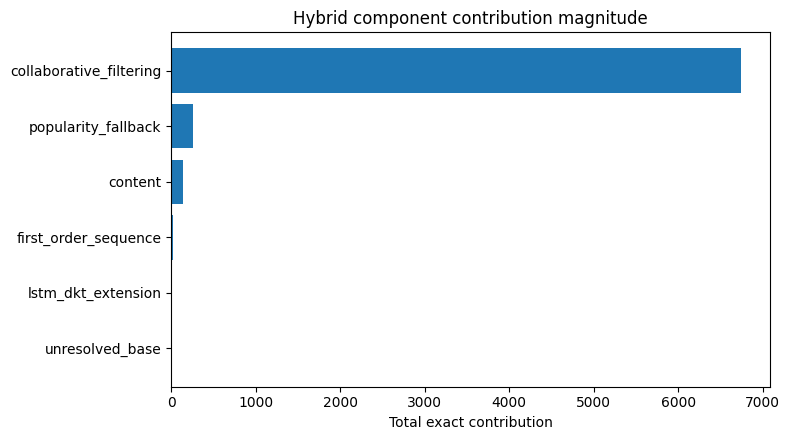

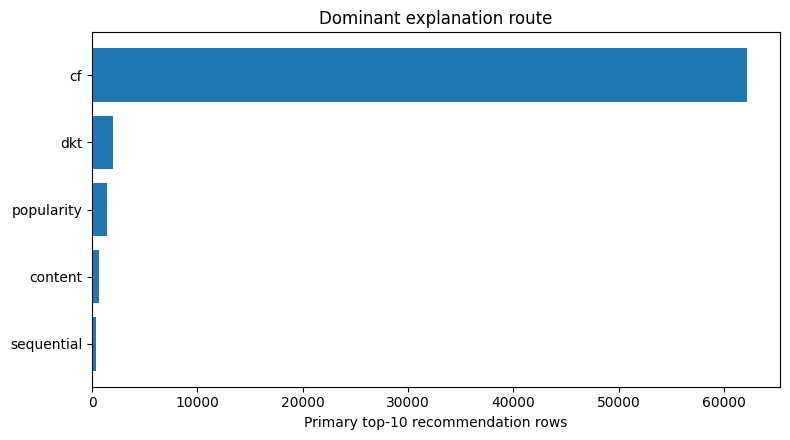

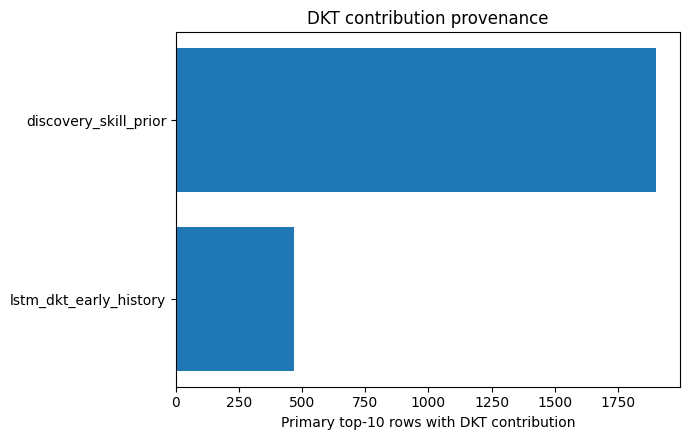

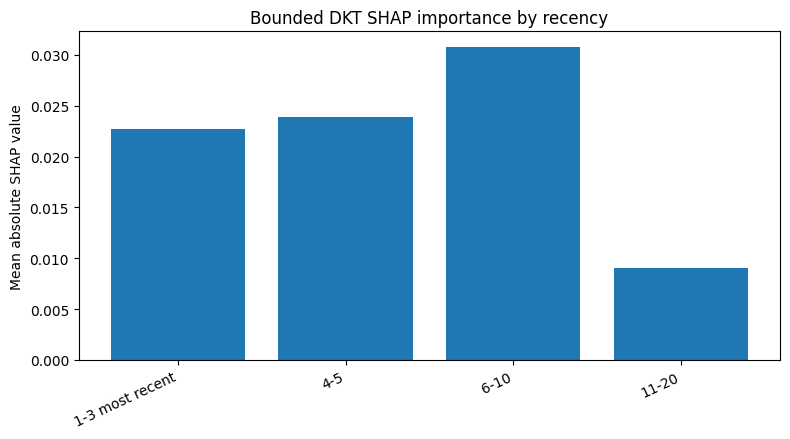

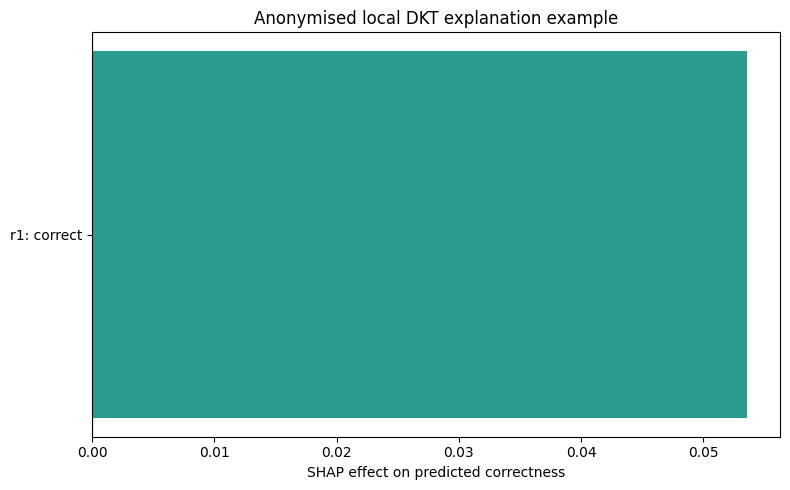

,Artifact,File,Rows,Bytes
0,recommendation_explanations,recommendation_explanations.parquet,533360,17256145
1,hybrid_component_attributions,hybrid_component_attributions.parquet,533360,2627754
2,dkt_shap_event_attributions,dkt_shap_event_attributions.parquet,137,12413
3,global_component_summary,global_component_summary.csv,6,719
4,global_shap_summary,global_shap_summary.csv,10,940
5,route_summary,route_summary.csv,40,3266
6,explanation_coverage,explanation_coverage.csv,2,421
7,warning_summary,warning_summary.csv,5,190
8,explanation_quality_metrics,explanation_quality_metrics.csv,9,498
9,explanation_examples,explanation_examples.csv,9,3209


Phase 7 artifacts saved to: /content/drive/MyDrive/datasets/explainable_recommendation_outputs


13754

In [18]:
figure_paths = {
    'component_contribution_figure': FIGURE_ROOT / 'global_component_contributions.png',
    'route_frequency_figure': FIGURE_ROOT / 'dominant_route_frequency.png',
    'dkt_provenance_figure': FIGURE_ROOT / 'dkt_state_provenance.png',
    'shap_summary_figure': FIGURE_ROOT / 'dkt_shap_recency_summary.png',
    'local_shap_example_figure': FIGURE_ROOT / 'local_dkt_shap_example.png',
}

plt.figure(figsize=(8, 4.5))
plot_frame = global_component_summary.sort_values('TotalContribution')
plt.barh(plot_frame['Component'], plot_frame['TotalContribution'])
plt.xlabel('Total exact contribution')
plt.title('Hybrid component contribution magnitude')
plt.tight_layout()
plt.savefig(figure_paths['component_contribution_figure'], dpi=180)
plt.show()
plt.close()

plt.figure(figsize=(8, 4.5))
route_plot = (
    primary_explanations['dominant_component'].value_counts().sort_values()
)
plt.barh(route_plot.index, route_plot.values)
plt.xlabel('Primary top-10 recommendation rows')
plt.title('Dominant explanation route')
plt.tight_layout()
plt.savefig(figure_paths['route_frequency_figure'], dpi=180)
plt.show()
plt.close()

plt.figure(figsize=(7, 4.5))
provenance_plot = (
    primary_explanations.loc[
        primary_explanations['dkt_attribution'].gt(0), 'dkt_state_source'
    ].fillna('no_state').value_counts().sort_values()
)
plt.barh(provenance_plot.index, provenance_plot.values)
plt.xlabel('Primary top-10 rows with DKT contribution')
plt.title('DKT contribution provenance')
plt.tight_layout()
plt.savefig(figure_paths['dkt_provenance_figure'], dpi=180)
plt.show()
plt.close()

plt.figure(figsize=(8, 4.5))
if not global_shap_summary.empty:
    shap_plot = (
        global_shap_summary.groupby('RecencyBand', observed=True)[
            'MeanAbsoluteShap'
        ].mean()
    )
    plt.bar(shap_plot.index.astype(str), shap_plot.values)
    plt.ylabel('Mean absolute SHAP value')
    plt.xticks(rotation=25, ha='right')
else:
    plt.text(0.5, 0.5, 'No genuine-LSTM SHAP cases available',
             ha='center', va='center')
    plt.xticks([])
    plt.yticks([])
plt.title('Bounded DKT SHAP importance by recency')
plt.tight_layout()
plt.savefig(figure_paths['shap_summary_figure'], dpi=180)
plt.show()
plt.close()

plt.figure(figsize=(8, 5))
if not dkt_shap_event_attributions.empty:
    example_case_id = int(dkt_shap_event_attributions['shap_case_id'].min())
    local_plot = dkt_shap_event_attributions[
        dkt_shap_event_attributions['shap_case_id'].eq(example_case_id)
    ].nlargest(10, 'AbsoluteShapValue').sort_values('ShapValue')
    labels = [
        f"r{row.recency_rank}: {'correct' if row.event_correct else 'incorrect'}"
        for row in local_plot.itertuples(index=False)
    ]
    colours = np.where(local_plot['ShapValue'].gt(0), '#2a9d8f', '#e76f51')
    plt.barh(labels, local_plot['ShapValue'], color=colours)
    plt.xlabel('SHAP effect on predicted correctness')
    plt.axvline(0, color='black', linewidth=0.8)
    plt.title('Anonymised local DKT explanation example')
else:
    plt.text(0.5, 0.5, 'No genuine-LSTM SHAP case available',
             ha='center', va='center')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.savefig(figure_paths['local_shap_example_figure'], dpi=180)
plt.show()
plt.close()

artifact_paths = {
    'recommendation_explanations': OUTPUT_ROOT / 'recommendation_explanations.parquet',
    'hybrid_component_attributions': OUTPUT_ROOT / 'hybrid_component_attributions.parquet',
    'dkt_shap_event_attributions': OUTPUT_ROOT / 'dkt_shap_event_attributions.parquet',
    'global_component_summary': OUTPUT_ROOT / 'global_component_summary.csv',
    'global_shap_summary': OUTPUT_ROOT / 'global_shap_summary.csv',
    'route_summary': OUTPUT_ROOT / 'route_summary.csv',
    'explanation_coverage': OUTPUT_ROOT / 'explanation_coverage.csv',
    'warning_summary': OUTPUT_ROOT / 'warning_summary.csv',
    'explanation_quality_metrics': OUTPUT_ROOT / 'explanation_quality_metrics.csv',
    'explanation_examples': OUTPUT_ROOT / 'explanation_examples.csv',
    'sequence_reconstruction_audit': OUTPUT_ROOT / 'sequence_reconstruction_audit.csv',
    'shap_stability': OUTPUT_ROOT / 'shap_stability.csv',
    'config': OUTPUT_ROOT / 'phase7_config.json',
    **figure_paths,
}

recommendation_explanations.to_parquet(
    artifact_paths['recommendation_explanations'],
    index=False, compression='snappy',
)
hybrid_attributions.to_parquet(
    artifact_paths['hybrid_component_attributions'],
    index=False, compression='snappy',
)
dkt_shap_event_attributions.to_parquet(
    artifact_paths['dkt_shap_event_attributions'],
    index=False, compression='snappy',
)
global_component_summary.to_csv(
    artifact_paths['global_component_summary'], index=False
)
global_shap_summary.to_csv(artifact_paths['global_shap_summary'], index=False)
route_summary.to_csv(artifact_paths['route_summary'], index=False)
explanation_coverage.to_csv(
    artifact_paths['explanation_coverage'], index=False
)
warning_summary.to_csv(artifact_paths['warning_summary'], index=False)
explanation_quality_metrics.to_csv(
    artifact_paths['explanation_quality_metrics'], index=False
)
explanation_examples.to_csv(
    artifact_paths['explanation_examples'], index=False
)
sequence_reconstruction_audit.to_csv(
    artifact_paths['sequence_reconstruction_audit'], index=False
)
shap_stability.to_csv(artifact_paths['shap_stability'], index=False)

phase7_config = {
    'phase': 7,
    'selected_project_model': selected_model,
    'selected_target_success': selected_target,
    'selected_dkt_weight': selected_weight_from_handoff,
    'primary_candidate_policy': PRIMARY_POLICY,
    'primary_relevance_definition': PRIMARY_RELEVANCE,
    'primary_k': PRIMARY_K,
    'exact_explanation_scope': 'all_saved_phase6_recommendations',
    'shap_target': 'lstm_dkt_supporting_skill_predicted_correctness',
    'shap_method': 'kernel_shap_recent_event_token_masking',
    'shap_reference': 'recent_window_masked_with_older_history_fixed',
    'shap_learners': int(len(shap_cases)),
    'shap_recent_events': SHAP_RECENT_EVENTS,
    'shap_nsamples': SHAP_NSAMPLES,
    'random_state': RANDOM_STATE,
    'tensorflow_version': tf.__version__,
    'shap_version': shap.__version__,
    'uses_validation_future_features': False,
    'causal_claim': False,
}
with open(artifact_paths['config'], 'w', encoding='utf-8') as file:
    json.dump(phase7_config, file, indent=2)

manifest_rows = []
for name, path in artifact_paths.items():
    if path.suffix == '.parquet':
        rows = pq.ParquetFile(path).metadata.num_rows
    elif path.suffix == '.csv':
        rows = len(pd.read_csv(path))
    else:
        rows = 1
    manifest_rows.append({
        'Artifact': name,
        'File': str(path.relative_to(OUTPUT_ROOT)),
        'Rows': rows,
        'Bytes': path.stat().st_size,
    })
artifact_manifest = pd.DataFrame(manifest_rows)
artifact_manifest.to_csv(OUTPUT_ROOT / 'artifact_manifest.csv', index=False)
display(artifact_manifest)
print('Phase 7 artifacts saved to:', OUTPUT_ROOT)

del sample_events
gc.collect()